## 1. Setup and imports


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from collections import defaultdict
from scipy.stats import ttest_ind


## 2. Data preparation


In [2]:
# 757 subjects x 147 columns
# Sex encoding: 0=Male (privileged), 1=Female (unprivileged)
df = pd.read_csv("data_4mod_MCIvsAD.csv")
print(df.shape)
df.head()

(757, 147)


,PTID,DIAGNOSIS,Sex,age,DXNODEP,DXMCI,DXMPTR1,DXMPTR2,DXMPTR3,DXMPTR4,...,RIGHT_BA36_NS,RIGHT_PHC_VOL,RIGHT_PHC_NS,RIGHT_SULCUS_VOL,RIGHT_SULCUS_NS,RIGHT_CA_VOL,RIGHT_CA_NS,RIGHT_HIPP_VOL,RIGHT_HIPP_NS,ICV
0,002_S_1155,0,0,57.9,0,0,1,1,1,1,...,12.0,0.040663,7.0,0.017779,18.0,0.094855,20.0,0.153476,20.0,1536260.810
1,002_S_4229,0,0,66.4,0,0,1,0,1,1,...,14.0,0.043713,8.0,0.015407,20.0,0.087257,21.0,0.132635,21.0,1447939.000
2,002_S_4473,0,0,74.8,0,0,1,1,1,1,...,13.0,0.053020,8.0,0.026710,20.0,0.077603,21.0,0.137151,21.0,1678392.749
3,002_S_4654,0,1,75.5,0,0,1,1,1,1,...,11.0,0.045150,8.0,0.027749,19.0,0.067913,19.0,0.119390,19.0,1548503.921
4,002_S_4799,0,0,81.3,0,0,1,0,1,1,...,13.0,0.043899,7.0,0.025049,18.0,0.086488,19.0,0.133770,19.0,1560673.616


In [3]:
protected_attr = "Sex"
target = "DIAGNOSIS"

In [4]:
# Drop 12 metadata columns
df = df.drop(['PTID',  'PTCOGBEG','DXMDUE', 'DXMCI', 'DXAD', 'DXAPP', 'DXDDUE', 'DXDSEV', 'PTADDX', 'ICV', 'PTHAND', 'CDRSB',
              'DXMPTR1', 'DXMPTR2', 'DXMPTR3', 'DXMPTR4', 'DXMPTR5', 'DXMPTR6'], axis=1) 
print(df.shape)
df.head()

(757, 129)


,DIAGNOSIS,Sex,age,DXNODEP,DXPARK,DXPDES,DXPCOG,DXPATYP,DXDEP,DXOTHDEM,...,RIGHT_BA36_VOL,RIGHT_BA36_NS,RIGHT_PHC_VOL,RIGHT_PHC_NS,RIGHT_SULCUS_VOL,RIGHT_SULCUS_NS,RIGHT_CA_VOL,RIGHT_CA_NS,RIGHT_HIPP_VOL,RIGHT_HIPP_NS
0,0,0,57.9,0,0,0,0,0,0,0,...,0.099781,12.0,0.040663,7.0,0.017779,18.0,0.094855,20.0,0.153476,20.0
1,0,0,66.4,0,0,0,0,0,0,0,...,0.122244,14.0,0.043713,8.0,0.015407,20.0,0.087257,21.0,0.132635,21.0
2,0,0,74.8,0,0,0,0,0,0,0,...,0.093440,13.0,0.053020,8.0,0.026710,20.0,0.077603,21.0,0.137151,21.0
3,0,1,75.5,0,0,0,0,0,0,0,...,0.059399,11.0,0.045150,8.0,0.027749,19.0,0.067913,19.0,0.119390,19.0
4,0,0,81.3,0,0,0,0,0,0,0,...,0.127571,13.0,0.043899,7.0,0.025049,18.0,0.086488,19.0,0.133770,19.0


In [5]:
# DIAGNOSIS = target; all remaining columns = features
X = df.drop(columns=['DIAGNOSIS'], axis=1)
y = df['DIAGNOSIS']

## 3. Model and cross-validation


In [6]:
model = SVC()

In [7]:
# 10-fold stratified cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [8]:
# Initialize storage
groups = df[protected_attr].unique()
group_metrics = defaultdict(lambda: {"TPR": [], "FPR": [], "StatParity": []})                  

for train_idx, test_idx in kf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    protected_test = df.iloc[test_idx][protected_attr]
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    for group in protected_test.unique():
        idx = protected_test == group
        y_true_g = y_test[idx]
        y_pred_g = preds[idx]
        if len(y_true_g) == 0:
            continue
        
        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_true_g, y_pred_g, labels=[0,1]).ravel()
        
        # Metrics
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        stat_parity = (tp + fp) / len(y_true_g)
        
        # Append to dictionary
        group_metrics[group]["TPR"].append(tpr)
        group_metrics[group]["FPR"].append(fpr)
        group_metrics[group]["StatParity"].append(stat_parity)

## 4. Fairness dashboard



Descriptive statistics (mean +/- std):
 Group  TPR_mean  TPR_std  FPR_mean  FPR_std  StatParity_mean  StatParity_std
     0  0.495076 0.093350  0.006364 0.012745         0.108552        0.026674
     1  0.429246 0.121134  0.023266 0.025658         0.105207        0.036977


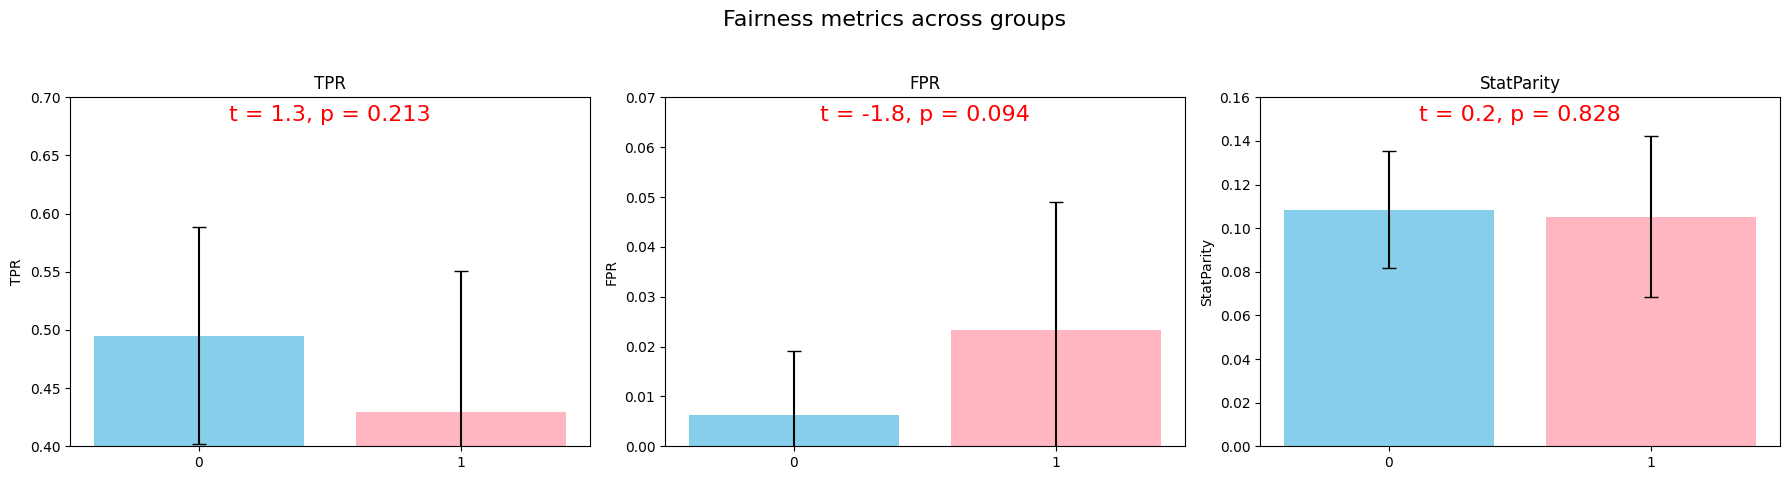

In [9]:
def fairness_dashboard(group_metrics_dict):
    """Plot TPR, FPR, and Statistical Parity per group with mean +/- std.

    Annotates each subplot with a t-test p-value comparing the first
    two groups.
    """
    metrics = ["TPR", "FPR", "StatParity"]
    groups = list(group_metrics_dict.keys())
    n = len(metrics)

    ylims = {"TPR": (0.4, 0.7), "FPR": (0, 0.07), "StatParity": (0.0, 0.16)}
    colours = ["skyblue", "lightpink", "lightgreen", "orange"]

    # Descriptive statistics table
    stats = []
    for g in groups:
        row = {"Group": g}
        for m in metrics:
            vals = group_metrics_dict[g][m]
            row[f"{m}_mean"] = np.mean(vals)
            row[f"{m}_std"] = np.std(vals)
        stats.append(row)

    print("\nDescriptive statistics (mean +/- std):")
    print(pd.DataFrame(stats).to_string(index=False))

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))

    for ax, metric in zip(axes, metrics):
        means = [np.mean(group_metrics_dict[g][metric]) for g in groups]
        stds = [np.std(group_metrics_dict[g][metric]) for g in groups]
        x = np.arange(len(groups))

        ax.bar(
            x, means, yerr=stds, capsize=5,
            color=colours[: len(groups)]
        )
        ax.set_xticks(x)
        ax.set_xticklabels(groups)
        ax.set_ylim(*ylims[metric])
        ax.set_ylabel(metric)
        ax.set_title(metric)

        if len(groups) >= 2:
            t_stat, p_val = ttest_ind(
                group_metrics_dict[groups[0]][metric],
                group_metrics_dict[groups[1]][metric],
                equal_var=True,
            )
            ax.text(
                0.5, 0.95,
                f"t = {t_stat:.1f}, p = {p_val:.3f}",
                ha="center", va="center",
                transform=ax.transAxes, fontsize=16, color="red",
            )

    plt.suptitle("Fairness metrics across groups", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1.0, 0.95])
    plt.show()


fairness_dashboard(group_metrics)
